In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:


import zipfile

zip_path = "/content/drive/MyDrive/processed (1).zip"
extract_path = "/content/processed"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import os
import time
import json
import torch
import torchvision
from torch import nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from datetime import timedelta
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")


In [7]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
import gc


In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch
import random
from collections import defaultdict

image_size = 128
batch_size = 128
sample_size = 50000
epochs = 50

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

full_dataset = datasets.ImageFolder(root="/content/processed/processed/train", transform=transform)

classes_to_keep = ['food', 'drink', 'inside', 'outside']
class_to_idx = full_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

class_indices = defaultdict(list)
for idx, (_, label) in enumerate(full_dataset.samples):
    class_name = full_dataset.classes[label]
    if class_name in classes_to_keep:
        class_indices[class_name].append(idx)

sample_per_class = sample_size // len(classes_to_keep)
final_indices = []
for cls in classes_to_keep:
    cls_indices = class_indices[cls]
    if len(cls_indices) < sample_per_class:
        raise ValueError(f"Not enough samples in class '{cls}' to sample {sample_per_class}")
    final_indices.extend(random.sample(cls_indices, sample_per_class))

# Create a mapping from original class indices to new class indices
original_to_new_idx = {class_to_idx[cls]: i for i, cls in enumerate(classes_to_keep)}

# Create a custom dataset that applies the new class mapping
class MappedSubset(Subset):
    def __init__(self, dataset, indices, transform=None):
        super().__init__(dataset, indices)
        self.transform = transform

    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        new_label = original_to_new_idx[label]
        if self.transform:
            image = self.transform(image)
        return image, new_label

dataset = MappedSubset(full_dataset, final_indices, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

print("Classes used:", classes_to_keep)
print(f"Total samples used: {len(dataset)}")
print(f"Samples per class: {sample_per_class}")

Classes used: ['food', 'drink', 'inside', 'outside']
Total samples used: 50000
Samples per class: 12500


In [9]:
# === Generator ===
class Generator(nn.Module):
    def __init__(self, classes_to_keep, z_dim=100):
        super().__init__()
        self.label_embed = nn.Embedding(len(classes_to_keep), z_dim)
        self.model = nn.Sequential(
            nn.Linear(z_dim * 2, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),
            nn.Linear(1024, 3 * 64 * 64),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_embedding = self.label_embed(labels)
        x = torch.cat([z, label_embedding], dim=1)
        out = self.model(x)
        return out.view(-1, 3, 64, 64)

In [10]:
# === Discriminator ===
class Discriminator(nn.Module):
    def __init__(self, classes_to_keep):
        super().__init__()
        self.label_embed = nn.Embedding(len(classes_to_keep), 3 * 64 * 64)
        self.model = nn.Sequential(
            nn.Linear(2 * 3 * 64 * 64, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        label_embedding = self.label_embed(labels)
        img_flat = img.view(img.size(0), -1)
        d_input = torch.cat([img_flat, label_embedding], dim=1)
        return self.model(d_input)

In [11]:
# === Dataset Loading ===
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = datasets.ImageFolder(root="/content/processed/processed/train", transform=transform)
subset_indices = list(range(min(10000, len(dataset))))
dataset = Subset(dataset, subset_indices)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, pin_memory=True)

In [12]:
# === Model Setup ===
z_dim = 100
classes_to_keep = ["food", "drink", "inside", "outside", "people"]
num_classes = len(classes_to_keep)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator(classes_to_keep, z_dim=z_dim).to(device)
D = Discriminator(classes_to_keep).to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

fixed_noise = torch.randn(num_classes, z_dim).to(device)
fixed_labels = torch.arange(num_classes).to(device)


In [13]:
# === Train Loop ===
epochs = 10
os.makedirs("generated_samples", exist_ok=True)

for epoch in range(epochs):
    start_time = time.time()

    for real_imgs, labels in dataloader:
        real_imgs, labels = real_imgs.to(device), labels.to(device)
        batch_size = real_imgs.size(0)

        # === Train Discriminator ===
        z = torch.randn(batch_size, z_dim).to(device)
        fake_imgs = G(z, labels)

        real_loss = criterion(D(real_imgs, labels), torch.ones((batch_size, 1), device=device))
        fake_loss = criterion(D(fake_imgs.detach(), labels), torch.zeros((batch_size, 1), device=device))
        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # === Train Generator ===
        g_loss = criterion(D(fake_imgs, labels), torch.ones((batch_size, 1), device=device))

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    end_time = time.time()
    print(f" Epoch {epoch+1}/{epochs} | Gen Loss: {g_loss.item():.4f} | Disc Loss: {d_loss.item():.4f} | Time: {end_time - start_time:.2f}s")

    # Save sample images every 2 epochs
    if (epoch + 1) % 2 == 0:
        with torch.no_grad():
            gen_imgs = G(fixed_noise, fixed_labels).detach().cpu()
            grid = utils.make_grid(gen_imgs, nrow=num_classes, normalize=True)
            utils.save_image(grid, f"generated_samples/epoch_{epoch+1}.png")

    # Clear GPU cache and memory fragments
    torch.cuda.empty_cache()
    gc.collect()

 Epoch 1/10 | Gen Loss: 2.2852 | Disc Loss: 0.3706 | Time: 56.42s
 Epoch 2/10 | Gen Loss: 1.0324 | Disc Loss: 0.7142 | Time: 52.22s
 Epoch 3/10 | Gen Loss: 1.1927 | Disc Loss: 0.7777 | Time: 53.11s
 Epoch 4/10 | Gen Loss: 1.5661 | Disc Loss: 0.3898 | Time: 53.15s
 Epoch 5/10 | Gen Loss: 1.0951 | Disc Loss: 0.9894 | Time: 52.18s
 Epoch 6/10 | Gen Loss: 1.1196 | Disc Loss: 1.1112 | Time: 52.32s
 Epoch 7/10 | Gen Loss: 1.0936 | Disc Loss: 0.6117 | Time: 52.23s
 Epoch 8/10 | Gen Loss: 1.3131 | Disc Loss: 0.5573 | Time: 52.09s
 Epoch 9/10 | Gen Loss: 1.3664 | Disc Loss: 0.5399 | Time: 52.27s
 Epoch 10/10 | Gen Loss: 1.3627 | Disc Loss: 0.5638 | Time: 52.31s


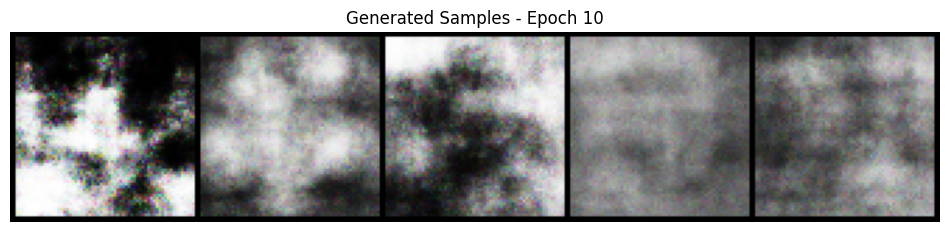

In [14]:
 # Display in Colab
import numpy as np
npimg = grid.numpy()
plt.figure(figsize=(12, 4))
plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.axis('off')
plt.title(f"Generated Samples - Epoch {epoch+1}")
plt.show()

hyperparameter tuning

In [15]:
import itertools

param_grid = {
    'learning_rate': [0.0002, 0.0001],
    'batch_size': [64, 128],
    'z_dim': [100, 128]
}
param_combinations = list(itertools.product(*param_grid.values()))


In [19]:
import itertools
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Define the hyperparameter search space
param_grid = {
    'learning_rate': [0.0002, 0.0001],
    'batch_size': [64, 128],
    'z_dim': [100, 128]
}
param_combinations = list(itertools.product(*param_grid.values()))

# Store results here
tuning_results = []

# Loop through each hyperparameter combination
for i, (lr, batch_size, z_dim) in enumerate(param_combinations):
    print(f"\n Config {i+1}/{len(param_combinations)}: LR={lr}, Batch={batch_size}, z_dim={z_dim}")

    # Initialize generator and discriminator with required arguments
    G = Generator(z_dim=z_dim, classes_to_keep=classes_to_keep).to(device)
    D = Discriminator(classes_to_keep=classes_to_keep).to(device)

    # Loss and optimizers
    criterion = nn.BCELoss()
    optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

    # Create temp dataloader with selected batch size
    temp_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Train each config for 2 epochs
    for epoch in range(2):
        for real_imgs, labels in temp_loader:
            real_imgs, labels = real_imgs.to(device), labels.to(device)
            b_size = real_imgs.size(0)

            # === Train Discriminator ===
            z = torch.randn(b_size, z_dim).to(device)
            fake_imgs = G(z, labels)

            real_loss = criterion(D(real_imgs, labels), torch.ones((b_size, 1), device=device))
            fake_loss = criterion(D(fake_imgs.detach(), labels), torch.zeros((b_size, 1), device=device))
            d_loss = (real_loss + fake_loss) / 2

            optimizer_D.zero_grad()
            d_loss.backward()
            optimizer_D.step()

            # === Train Generator ===
            g_loss = criterion(D(fake_imgs, labels), torch.ones((b_size, 1), device=device))

            optimizer_G.zero_grad()
            g_loss.backward()
            optimizer_G.step()

    # Log the result for this config
    tuning_results.append({
        'learning_rate': lr,
        'batch_size': batch_size,
        'z_dim': z_dim,
        'g_loss': g_loss.item(),
        'd_loss': d_loss.item()
    })

# Convert to DataFrame and sort
results_df = pd.DataFrame(tuning_results)
results_df = results_df.sort_values(by='g_loss')
display(results_df)



 Config 1/8: LR=0.0002, Batch=64, z_dim=100

 Config 2/8: LR=0.0002, Batch=64, z_dim=128

 Config 3/8: LR=0.0002, Batch=128, z_dim=100

 Config 4/8: LR=0.0002, Batch=128, z_dim=128

 Config 5/8: LR=0.0001, Batch=64, z_dim=100

 Config 6/8: LR=0.0001, Batch=64, z_dim=128

 Config 7/8: LR=0.0001, Batch=128, z_dim=100

 Config 8/8: LR=0.0001, Batch=128, z_dim=128


,learning_rate,batch_size,z_dim,g_loss,d_loss
4,0.0001,64,100,1.575197,0.372426
1,0.0002,64,128,1.739416,0.333065
2,0.0002,128,100,1.799481,0.269575
0,0.0002,64,100,2.145915,0.541113
5,0.0001,64,128,2.496209,0.219995
7,0.0001,128,128,2.694550,0.124002
6,0.0001,128,100,3.155195,1.037853
3,0.0002,128,128,7.429769,3.041106


In [20]:
results_df = pd.DataFrame(tuning_results)
results_df = results_df.sort_values(by='g_loss')  # You can sort by g_loss or d_loss
display(results_df)


,learning_rate,batch_size,z_dim,g_loss,d_loss
4,0.0001,64,100,1.575197,0.372426
1,0.0002,64,128,1.739416,0.333065
2,0.0002,128,100,1.799481,0.269575
0,0.0002,64,100,2.145915,0.541113
5,0.0001,64,128,2.496209,0.219995
7,0.0001,128,128,2.694550,0.124002
6,0.0001,128,100,3.155195,1.037853
3,0.0002,128,128,7.429769,3.041106
